# Supplemental Material Figure - All Panorpa

Scale Factor    | Mean     | Median   | Std     
------------------------------------------------
0.4             | 0.6166   | 0.6200   | 0.1656  
0.6             | 0.5648   | 0.5825   | 0.1523  
0.8             | 0.4989   | 0.5130   | 0.1599  
1.0             | 0.4396   | 0.4670   | 0.1651  
------------------------------------------------


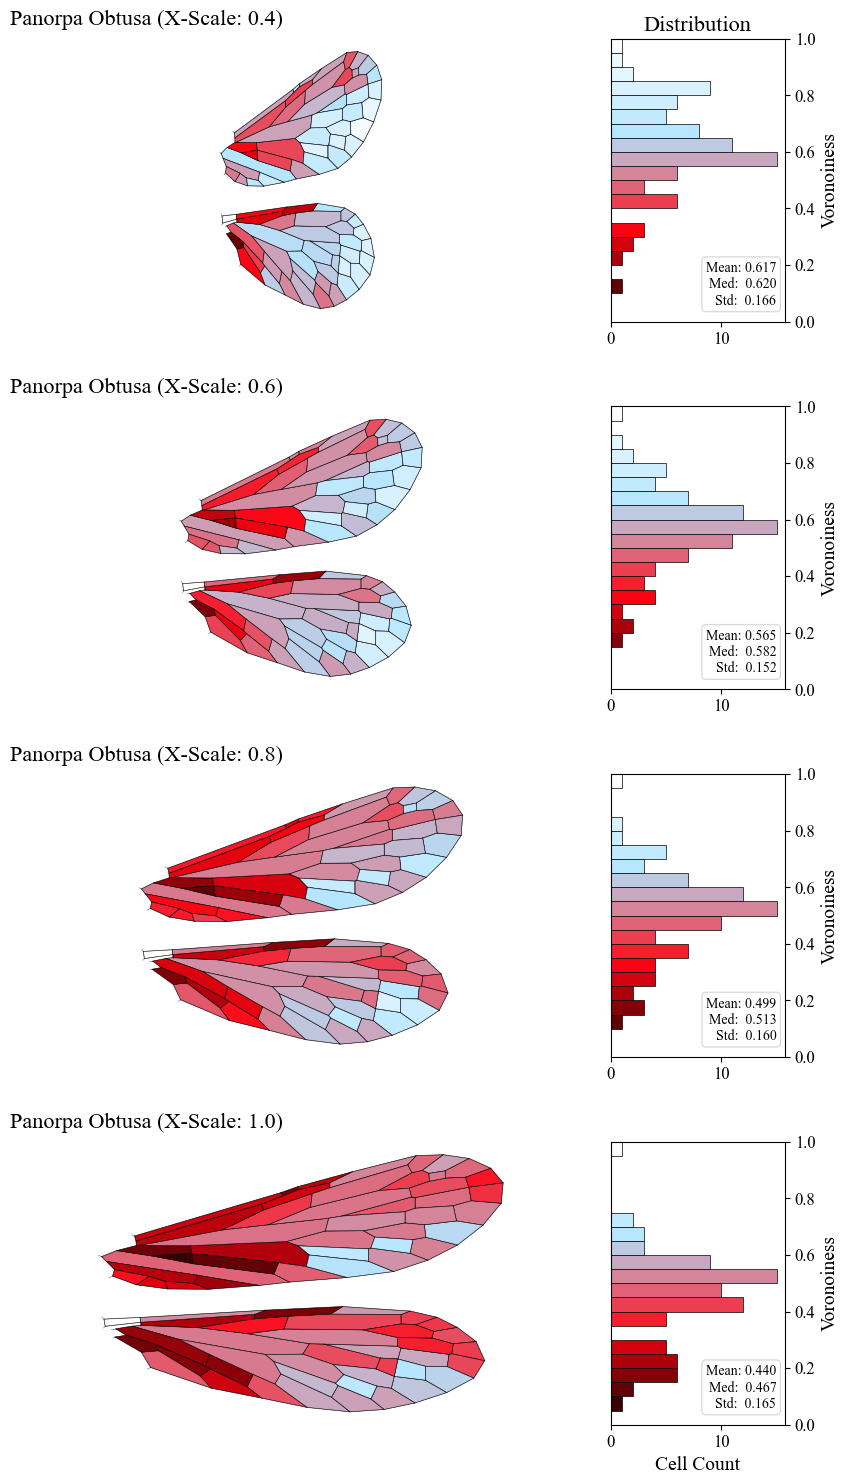


Scaling analysis successfully processed and plotted in a 4x1 vertical grid!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.path import Path
from matplotlib.collections import PolyCollection
from skimage import io, color, filters, morphology, util
from scipy.sparse import coo_matrix
import warnings

# Suppress the skimage matmul RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# Suppress matplotlib tight_layout UserWarnings
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout.*")

# ================================================================
# Setup Publication Styling, Species & Colormap
# ================================================================
# Apply academic journal font settings globally
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 12,          # Global font size
    'axes.labelsize': 14,     # X and Y axis labels
    'axes.titlesize': 16,     # Title size
    'xtick.labelsize': 12,    # X tick labels
    'ytick.labelsize': 12,    # Y tick labels
    'figure.titlesize': 16
})

base_name = "Panorpa Obtusa"
scales = [0.4, 0.6, 0.8, 1.0]

# Standard normalization and Viridis colormap
norm = Normalize(vmin=0.0, vmax=1.0)
cmap_viridis = mcolors.LinearSegmentedColormap.from_list(
    "PuBuRed",
    ["#000000","#FF0211","#B5E5FF","#FFFFFF"]
)

# ================================================================
# Figure Setup (4x1 Scaling Grid -> 4x2 Subplot Grid)
# ================================================================
num_scales = len(scales)

# 4 rows (1 per scale), 2 columns (Wing, Histogram)
fig, axes = plt.subplots(
    nrows=num_scales, 
    ncols=2, 
    figsize=(10, 18), 
    gridspec_kw={'width_ratios': [5, 1.5], 'wspace': 0.05, 'hspace': 0.3}
)

print(f"{'Scale Factor':<15} | {'Mean':<8} | {'Median':<8} | {'Std':<8}")
print("-" * 48)

# ================================================================
# Main Processing Loop
# ================================================================
for idx, scale in enumerate(scales):
    
    # Assign the current axes (row = idx, col = 0 for wing, 1 for hist)
    ax_wing = axes[idx, 0]
    ax_hist = axes[idx, 1]
    
    # ------------------------------------------------------------
    # 0. Load image & skeletonize
    # ------------------------------------------------------------
    IMG_PATH = base_name + ".png"
    
    try:
        img = io.imread(IMG_PATH)
    except FileNotFoundError:
        print(f"Warning: File {IMG_PATH} not found. Skipping.")
        continue

    if img.ndim == 3 and img.shape[-1] == 4:
        rgb = util.img_as_float(img[..., :3])
        alpha = util.img_as_float(img[..., 3])
        if alpha.ndim == 2:
            alpha = alpha[..., None]
        rgb = rgb * alpha + (1 - alpha)
        gray = color.rgb2gray(rgb)
    elif img.ndim == 3:
        gray = color.rgb2gray(util.img_as_float(img))
    else:
        gray = util.img_as_float(img)

    thr = filters.threshold_otsu(gray)
    bw = gray < thr
    if bw.mean() > 0.5:
        bw = ~bw

    bw = morphology.remove_small_objects(bw, min_size=8)
    skel = morphology.skeletonize(bw)
    H, W = skel.shape

    # ------------------------------------------------------------
    # 1. Skeleton adjacency
    # ------------------------------------------------------------
    ys, xs = np.where(skel)
    nodes = ys * W + xs
    node_set = set(nodes)
    nbrs8 = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    adj = {int(n): [] for n in nodes}
    for y, x in zip(ys, xs):
        a = int(y*W + x)
        for dy, dx in nbrs8:
            yy, xx = y+dy, x+dx
            if 0 <= yy < H and 0 <= xx < W:
                b = int(yy*W + xx)
                if b in node_set:
                    adj[a].append(b)

    deg = {n: len(adj[n]) for n in adj}
    vertices = [n for n, d in deg.items() if d != 2]
    Vset = set(vertices)

    def xy_from_id(n):
        return (n % W, n // W)

    def yx_from_id(n):
        return (n // W, n % W)

    # ------------------------------------------------------------
    # 2. Ridge tracing
    # ------------------------------------------------------------
    def walk_ridge(start_v, nxt):
        path = [start_v, nxt]
        prev, cur = start_v, nxt
        while cur not in Vset:
            nxts = [w for w in adj[cur] if w != prev]
            if not nxts:
                break
            prev, cur = cur, nxts[0]
            path.append(cur)
        return path

    half_seen = set()
    ridges = []
    ridge_id = 0
    MIN_LEN = 3

    for v in vertices:
        for u in adj[v]:
            he = (v, u)
            if he in half_seen:
                continue
            path = walk_ridge(v, u)
            for a, b in zip(path, path[1:]):
                half_seen.add((a, b))
                half_seen.add((b, a))
            v0 = path[0]
            vend = path[-1]
            if v0 in Vset and vend in Vset and v0 != vend and len(path) >= MIN_LEN:
                ridges.append({
                    "id": ridge_id,
                    "v0": int(v0),
                    "v1": int(vend),
                    "pixels": path[:],
                    "length": len(path),
                })
                ridge_id += 1

    # ------------------------------------------------------------
    # 3. Merge vertex pixels -> single vertex & APPLY SCALING
    # ------------------------------------------------------------
    vids = np.array(vertices, dtype=int)
    Nv = len(vids)
    id_to_idx = {int(v): i for i, v in enumerate(vids)}

    parent = np.arange(Nv)
    rank = np.zeros(Nv, int)

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            if rank[ra] < rank[rb]:
                parent[ra] = rb
            elif rank[ra] > rank[rb]:
                parent[rb] = ra
            else:
                parent[rb] = ra
                rank[ra] += 1

    for v in vids:
        i = id_to_idx[v]
        y, x = yx_from_id(v)
        for dy, dx in nbrs8:
            yy, xx = y+dy, x+dx
            if 0 <= yy < H and 0 <= xx < W:
                nb = int(yy*W + xx)
                if nb in Vset:
                    j = id_to_idx[nb]
                    union(i, j)

    comp_members = {}
    for i, v in enumerate(vids):
        r = find(i)
        comp_members.setdefault(r, []).append(i)

    new_vertex_of_old = {}
    new_vertices_xy = []
    for new_id, (rep, members) in enumerate(comp_members.items()):
        xs_list, ys_list = [], []
        for i in members:
            x, y = xy_from_id(int(vids[i]))
            xs_list.append(x); ys_list.append(y)
            new_vertex_of_old[int(vids[i])] = new_id
        new_vertices_xy.append((np.mean(xs_list), np.mean(ys_list)))

    new_vertices_xy = np.array(new_vertices_xy, float)
    
    # ---> APPLY X-AXIS SCALING HERE <---
    new_vertices_xy[:, 0] *= scale
    
    Nnew = len(new_vertices_xy)

    # ------------------------------------------------------------
    # 4. Remap ridges
    # ------------------------------------------------------------
    new_ridges = []
    pair_to_id = {}

    for r in ridges:
        a = new_vertex_of_old.get(r["v0"])
        b = new_vertex_of_old.get(r["v1"])
        if a is None or b is None or a == b:
            continue
        key = (a, b) if a < b else (b, a)
        if key in pair_to_id:
            rid = pair_to_id[key]
            if r["length"] > new_ridges[rid]["length"]:
                new_ridges[rid] = {
                    "id": rid, "v0": key[0], "v1": key[1],
                    "pixels": r["pixels"], "length": r["length"]
                }
        else:
            rid = len(new_ridges)
            pair_to_id[key] = rid
            new_ridges.append({
                "id": rid, "v0": key[0], "v1": key[1],
                "pixels": r["pixels"], "length": r["length"]
            })

    # ------------------------------------------------------------
    # 5. Vertex adjacency
    # ------------------------------------------------------------
    rows, cols, data = [], [], []
    for r in new_ridges:
        i, j = r["v0"], r["v1"]
        rows += [i,j]
        cols += [j,i]
        data += [1,1]

    A = coo_matrix((data,(rows,cols)), shape=(Nnew,Nnew)).tocsr()

    # ------------------------------------------------------------
    # 6. Build cells (faces)
    # ------------------------------------------------------------
    XY = new_vertices_xy
    N = XY.shape[0]

    nbrs_ccw = {i:[] for i in range(N)}
    for i in range(N):
        js = A.indices[A.indptr[i]:A.indptr[i+1]]
        if js.size == 0:
            continue
        xi, yi = XY[i]
        angles = np.arctan2(-(XY[js,1]-yi),(XY[js,0]-xi))
        order = np.argsort(angles)
        nbrs_ccw[i] = list(js[order])

    halfedges = {(i,j) for i in range(N) for j in nbrs_ccw[i]}
    visited = set()

    def face_walk(i_start, j_start):
        ring = []
        i, j = i_start, j_start
        while True:
            if (i,j) in visited:
                return None
            visited.add((i,j))
            ring.append(i)
            nbrs_j = nbrs_ccw[j]
            if not nbrs_j:
                return None
            try:
                k = nbrs_j.index(i)
            except ValueError:
                return None
            w = nbrs_j[(k-1) % len(nbrs_j)]
            i, j = j, w
            if (i,j) == (i_start,j_start):
                break
            if len(ring) > 4*N:
                return None
        return ring

    def polygon_area(coords):
        x = coords[:,0]; y = coords[:,1]
        return 0.5 * abs(np.dot(x, np.roll(y,-1)) - np.dot(y, np.roll(x,-1)))

    def canonical_cycle(vs):
        vs = list(vs)
        m = min(vs)
        idxs = [k for k,v in enumerate(vs) if v == m]
        rots = [tuple(vs[k:]+vs[:k]) for k in idxs]
        rvs = list(reversed(vs))
        idxs_r = [k for k,v in enumerate(rvs) if v == m]
        rots += [tuple(rvs[k:]+rvs[:k]) for k in idxs_r]
        return min(rots)

    raw = []
    for (i,j) in list(halfedges):
        if (i,j) in visited:
            continue
        ring = face_walk(i,j)
        if ring and len(ring)>=3:
            raw.append(ring)

    seen = set()
    cycles = []
    for ring in raw:
        key = canonical_cycle(ring)
        if key not in seen:
            seen.add(key)
            cycles.append(list(key))

    cells = []
    for ring in cycles:
        poly = XY[np.array(ring)]
        A_poly = polygon_area(poly)
        if A_poly < 5:  # Scaled area threshold
            continue
        path = Path(poly, closed=True)
        mask = np.ones(N,bool)
        mask[np.array(ring,int)] = False
        inside = path.contains_points(XY[mask]) if mask.any() else []
        if np.any(inside):
            continue
        x = poly[:,0]; y = poly[:,1]
        cross = x*np.roll(y,-1) - y*np.roll(x,-1)
        denom = cross.sum()
        if abs(denom) < 1e-9:
            cx, cy = x.mean(), y.mean()
        else:
            cx = ((x+np.roll(x,-1))*cross).sum()/(3*denom)
            cy = ((y+np.roll(y,-1))*cross).sum()/(3*denom)
        cells.append({"verts":ring, "area":A_poly, "centroid":(cx,cy)})

    Nc = len(cells)
    if Nc == 0:
        continue
        
    seeds0 = np.array([c["centroid"] for c in cells], float)

    # ------------------------------------------------------------
    # 7. Cell adjacency & edge mapping
    # ------------------------------------------------------------
    edge_to_cells = {}
    for ci,c in enumerate(cells):
        vs = c["verts"]
        for a,b in zip(vs, vs[1:]+vs[:1]):
            key = (a,b) if a<b else (b,a)
            edge_to_cells.setdefault(key,[]).append(ci)

    # ------------------------------------------------------------
    # 8. Perimeters + edge lengths + weights (L^2/(Pi*Pj))
    # ------------------------------------------------------------
    cell_perimeter = np.zeros(Nc)
    for ci,c in enumerate(cells):
        vs = c["verts"]
        per = 0
        for a,b in zip(vs, vs[1:]+vs[:1]):
            pa, pb = XY[a], XY[b]
            per += np.linalg.norm(pa-pb)
        cell_perimeter[ci] = per

    edge_length = {}
    for r in new_ridges:
        u,v = r["v0"], r["v1"]
        L = np.linalg.norm(XY[u]-XY[v])
        key = (u,v) if u<v else (v,u)
        edge_length[key] = L

    edge_weight = {}
    for key,cs in edge_to_cells.items():
        if len(cs)==2:
            ci,cj = cs
            Pi,Pj = cell_perimeter[ci], cell_perimeter[cj]
            L = edge_length.get(key, 0)
            if Pi > 0 and Pj > 0:
                w = (L*L)/(Pi*Pj)
                edge_weight[key] = w

    # ------------------------------------------------------------
    # 9. Reflection & Iteration
    # ------------------------------------------------------------
    def reflect_over_line(p,a,b):
        a = np.asarray(a,float)
        b = np.asarray(b,float)
        p = np.asarray(p,float)
        ab = b-a
        denom = np.dot(ab,ab)
        if denom==0:
            return p
        t = np.dot(p-a,ab)/denom
        proj = a + t*ab
        return 2*proj - p

    def iterate(seeds, steps=50, beta=0.1):
        seeds = seeds.copy()
        for _ in range(steps):
            new = seeds.copy()
            for i,c in enumerate(cells):
                vs = c["verts"]
                wsum = 0
                acc = np.zeros(2)
                for a,b in zip(vs, vs[1:]+vs[:1]):
                    key = (a,b) if a<b else (b,a)
                    cs = edge_to_cells.get(key,[])
                    if len(cs)!=2:
                        continue
                    j = cs[0] if cs[1]==i else cs[1] if cs[0]==i else None
                    if j is None:
                        continue
                    w = edge_weight.get(key,0)
                    if w<=0:
                        continue
                    r = reflect_over_line(seeds[j], XY[a], XY[b])
                    acc += w*r
                    wsum += w
                if wsum>0:
                    m = acc/wsum
                    new[i] = (1-beta)*seeds[i] + beta*m
            seeds = new
        return seeds

    final_seeds = iterate(seeds0, steps=200, beta=1)

    # ------------------------------------------------------------
    # 10. Voronoiness computation & Statistical Reporting
    # ------------------------------------------------------------
    voronoiness = np.zeros(Nc, float)

    for i, c in enumerate(cells):
        C = final_seeds[i]
        vs = c["verts"]
        wsum = 0.0
        acc = 0.0

        for a, b in zip(vs, vs[1:] + vs[:1]):
            key = (a,b) if a < b else (b,a)
            cs = edge_to_cells.get(key, [])
            if len(cs) != 2:
                continue

            j = cs[0] if cs[1] == i else cs[1] if cs[0] == i else None
            if j is None:
                continue
            
            N = final_seeds[j]
            M = reflect_over_line(N, XY[a], XY[b])
            w = 1

            d_CN = np.linalg.norm(C - N)
            d_CM = np.linalg.norm(C - M)
            
            if d_CN <= 1e-12:
                continue

            ratio = d_CM / d_CN
            acc += w * ratio
            wsum += w

        if wsum > 0:
            NV = acc / wsum
            voronoiness[i] = np.exp(-NV)
        else:
            voronoiness[i] = 0.5 
            
    # Calculate and Print Statistics
    v_mean = np.mean(voronoiness)
    v_med = np.median(voronoiness)
    v_std = np.std(voronoiness)
    print(f"{scale:<15.1f} | {v_mean:<8.4f} | {v_med:<8.4f} | {v_std:<8.4f}")

    # ================================================================
    # 11. Plotting inside the Grid
    # ================================================================
    
    # --- Wing Plot (Left Column) ---
    poly_verts = [XY[np.array(c["verts"])] for c in cells]

    pc = PolyCollection(poly_verts,
                        array=voronoiness,
                        cmap=cmap_viridis,
                        norm=norm,
                        edgecolor="black",
                        linewidth=0.3)

    ax_wing.add_collection(pc)

    for r in new_ridges:
        x0, y0 = XY[r["v0"]]
        x1, y1 = XY[r["v1"]]
        ax_wing.plot([x0, x1], [y0, y1], color="black", lw=0.6, alpha=0.4)

    ax_wing.set_title(f"{base_name} (X-Scale: {scale})", loc='left', pad=10)  
    ax_wing.invert_yaxis()
    ax_wing.axis("equal")
    ax_wing.axis("off")

    # --- Merged Colorbar & Histogram Plot (Right Column) ---
    n_hist, bins, patches = ax_hist.hist(voronoiness, bins=20, range=(0, 1), 
                                         orientation='horizontal', edgecolor="black", linewidth=0.5)

    for patch in patches:
        y_val = patch.get_y() + patch.get_height() / 2.0
        bar_color = cmap_viridis(norm(y_val))
        patch.set_facecolor(bar_color)

    ax_hist.set_ylim(0, 1)
    cbar_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax_hist.set_yticks(cbar_ticks)
    ax_hist.set_yticklabels([f"{t:.1f}" for t in cbar_ticks])
    
    ax_hist.yaxis.tick_right()
    ax_hist.yaxis.set_label_position("right")
    ax_hist.set_ylabel("Voronoiness")
    
    # Add Text Box with Stats to Histogram
    stats_text = f"Mean: {v_mean:.3f}\nMed:  {v_med:.3f}\nStd:  {v_std:.3f}"
    ax_hist.text(0.95, 0.05, stats_text, transform=ax_hist.transAxes, 
                 ha='right', va='bottom', fontsize=10, 
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey'))

    # Conditional logic for titles and labels based on grid row
    if idx == 0:
        ax_hist.set_title("Distribution")
        ax_hist.set_xlabel("")
    elif idx == num_scales - 1:
        ax_hist.set_xlabel("Cell Count")
    else:
        ax_hist.set_xlabel("")

# ================================================================
# Final Cleanup and Export
# ================================================================
print("-" * 48)
plt.tight_layout()
plt.savefig("Panorpa_Obtusa_Scaling_4x1.png", dpi=600, bbox_inches='tight')
plt.show()

print("\nScaling analysis successfully processed and plotted in a 4x1 vertical grid!")